## 錨泊、繫泊 試作

### def function

In [1]:
import folium
from folium.plugins import FastMarkerCluster

def show_stops_map(stops, zoom_start=4, center=(14, 120)):
    m = folium.Map(location=center, zoom_start=zoom_start, tiles="OpenStreetMap")
    color_map = {'anchorage': 'orange', 'moored': 'green', 'offshore': 'gray'}

    for _, r in stops.iterrows():
        c = color_map.get(r['stop_type'], 'blue')
        folium.CircleMarker(
            location=[r['center_lat'], r['center_lon']],
            radius=4, color=c, fill=True, fill_opacity=0.8,
            tooltip=f"{r['nearest_port']} | {r['stop_type']}",
            popup=folium.Popup(
                f"stop_id: {r['stop_id']}<br>"
                f"port: {r['nearest_port']}<br>"
                f"duration: {r['duration_sec']/3600:.2f} h<br>"
                f"r95: {r['r95_km']:.3f} km<br>"
                f"dh_std: {r['dh_std']:.1f}°<br>"
                f"dist_port: {r['dist_to_port_km']:.2f} km", max_width=300)
        ).add_to(m)
    return m

def show_voyage_map(df_with_vid, voyages, v_id, zoom_start=4):
    seg = df_with_vid[df_with_vid['voyage_id'] == v_id]
    if seg.empty: 
        return None
    latlon = seg[['Lat','Long']].values.tolist()
    center = [seg['Lat'].median(), seg['Long'].median()]
    m = folium.Map(location=center, zoom_start=zoom_start)

    # 航跡折線
    folium.PolyLine(latlon, weight=3, opacity=0.7).add_to(m)

    # 起點/終點
    folium.Marker(latlon[0], icon=folium.Icon(color='blue'), tooltip="Origin").add_to(m)
    folium.Marker(latlon[-1], icon=folium.Icon(color='red'), tooltip="Destination").add_to(m)

    return m


In [2]:
"""
main.py
-------
專案主程式，串接 data_loader、voyage_splitter、Trajectory_Recon、data_quality、
以及基於論文方法的港口事件與航程切分（voyage_port_pipeline）
"""

from pathlib import Path

# 自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import detect_stops, split_voyages, voyage_quality_checker
from data_quality import voyage_integrity_metrics
from Trajectory_Recon import TrajectoryReconstructor
from voyage_port_pipeline import (
    run_port_voyage_pipeline, PipelineConfig, StopTypeThreshold)

import pandas as pd


# ==== 港口清單路徑 ====
PORTS_CSV_PATH = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\filtered_ports.csv")

def load_ports_df(path: Path) -> pd.DataFrame:
    """
    讀取 filtered_ports.csv，欄位: name, unlocode, port_type, lat, lon
    - 正規化欄位名稱
    - 產生 port_name 欄位（由 name 映射）
    - 檢查 lat/lon 是否存在
    """
    df = pd.read_csv(path)
    # 欄位全轉小寫做對應，再保留原始大小寫
    lower = {c.lower(): c for c in df.columns}

    # 必要欄位檢查
    assert 'lat' in lower and 'lon' in lower, "ports_df 必須包含 lat, lon 欄位（小數度）"
    # 建立 port_name 欄位（由 name 映射），保留 unlocode / port_type
    if 'port_name' not in df.columns:
        if 'name' in lower:
            df = df.rename(columns={lower['name']: 'port_name'})
        else:
            # 極少數情形 name 不存在就用索引生成
            df['port_name'] = df.index.map(lambda i: f"PORT_{i}")

    # 欄位保留與命名一致化（可選）
    if 'unlocode' in lower and lower['unlocode'] != 'unlocode':
        df = df.rename(columns={lower['unlocode']: 'unlocode'})
    if 'port_type' in lower and lower['port_type'] != 'port_type':
        df = df.rename(columns={lower['port_type']: 'port_type'})
    if lower['lat'] != 'lat':
        df = df.rename(columns={lower['lat']: 'lat'})
    if lower['lon'] != 'lon':
        df = df.rename(columns={lower['lon']: 'lon'})

    # 基本清理：去掉缺 lat/lon 的列
    df = df.dropna(subset=['lat', 'lon']).reset_index(drop=True)
    return df


def main():
    # -----------------------------------
    # Step 1: 載入與前處理
    # -----------------------------------
    csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "Device_AB00030.csv"
    target_mmsi = 636012794

    print("載入與前處理資料中...")
    df = load_and_preprocess(csv_path, target_mmsi)
    print(f"清理後資料筆數: {len(df)}")

    # -----------------------------------
    # Step 2: 初步停泊判斷（供傳統切分與 QA 使用）
    # -----------------------------------
    print("執行停泊判斷...")
    stop_segments_initial = detect_stops(df)
    print(f"偵測到停泊區段數量: {len(stop_segments_initial)}")

    # -----------------------------------
    # Step 3: 傳統航程切分（供 QA / 缺口偵測使用）
    # -----------------------------------
    print("切分航程（傳統：停泊→航行→停泊）...")
    df_with_voyages, voyages_raw = split_voyages(df, stop_segments_initial)
    print(f"切分後航程數量: {len(voyages_raw)}")

    # -----------------------------------
    # Step 4: 航程 QA
    # -----------------------------------
    print("執行航程 QA 檢查...")
    voyages_qc = voyage_quality_checker(df_with_voyages, voyages_raw)
    print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")

    # 4.5 補充品質指標（訊號完整度等）
    voyages_qc_integrity = voyage_integrity_metrics(df_with_voyages, voyages_raw)
    voyages_merged = (
        voyages_raw
        .merge(voyages_qc, on="voyage_id", how="left")
        .merge(voyages_qc_integrity, on="voyage_id", how="left")
    )

    # -----------------------------------
    # Step 5: 航跡修復（時間缺口 R5）
    # -----------------------------------
    print("檢查並修復時間缺口 (R5_missing_time_gap)...")
    reconstructor = TrajectoryReconstructor()
    df_recon, gap_summary = reconstructor.reconstruct_voyages(
        df=df_with_voyages,
        voyages_summary=voyages_merged,
        target_reason="R5_missing_time_gap",
        verbose=True,
    )
    print(f"修復完成，共插入 {gap_summary['inserted_points'].sum()} 筆點")
    print("Gap Summary（前5列）:")
    print(gap_summary.head())

    # 之後流程建議以修復後的 df_recon 為主
    df_final = df_recon.copy()

    # -----------------------------------
    # Step 6: 讀取港口清單
    # -----------------------------------
    ports_df = load_ports_df(PORTS_CSV_PATH)
    print(f"載入港口清單：{len(ports_df)} 筆；欄位：{list(ports_df.columns)}")
    # 前幾列檢查（可註解）
    print(ports_df.head(3)[['port_name','unlocode','port_type','lat','lon']])

    # -----------------------------------
    # Step 7: 以論文方法的 pipeline 做「港口事件 + 航程（含錨泊）」切分
    #   * 重要：修復後請重新做停泊判斷，反映補點效果
    # -----------------------------------
    print("修復後重新執行停泊判斷（供港口事件流程使用）...")
    stop_segments_final = detect_stops(df_final)
    print(f"修復後偵測到停泊區段數量: {len(stop_segments_final)}")

    cfg = PipelineConfig(
        same_port_time_gap_hr=6.0,
        thresholds=StopTypeThreshold(
            in_port_km=2.0, anchorage_km=15.0,
            r95_small_km=0.10, r95_anchor_km=0.10,
            dh_std_moored_deg=10.0, dh_std_anchor_deg=15.0
        ),
        adaptive_by_port=False,       # 先關，穩定後再開
        mismatch_km_tol=5.0,
        compute_shore_distance=False  # 有 land_gdf 再開
    )

    out = run_port_voyage_pipeline(
        df=df_final,
        stop_segments=stop_segments_final,
        ports_df=ports_df,
        land_gdf=None,
        cfg=cfg
    )

    stops        = out['stops']
    port_events  = out['port_events']
    df_with_vid  = out['df_with_vid']
    voyages_ports = out['voyages']             # 以「港口事件」切出的航程（含錨泊概念）
    voyages_check = out['voyages_validated']   # 加上代表點雙重驗證欄位

    print(f"港口事件數量：{len(port_events)}，最終航程數量（事件切分）：{len(voyages_ports)}")

    # 需要的話你可以把這些存檔
    #df_final.to_csv("reconstructed_tracks.csv", index=False, encoding="utf-8-sig")
    #stops.to_csv("stop_events.csv", index=False, encoding="utf-8-sig")
    #port_events.to_csv("port_events.csv", index=False, encoding="utf-8-sig")
    #voyages_ports.to_csv("voyages_ports.csv", index=False, encoding="utf-8-sig")
    #voyages_check.to_csv("voyages_ports_validated.csv", index=False, encoding="utf-8-sig")

    m1 = show_stops_map(stops)               # 看停泊分類是否合理
    m1.save("stops_map.html")

    if len(voyages_ports) > 0:
        vid = voyages_ports.iloc[0]['voyage_id']
        m2 = show_voyage_map(df_with_vid, voyages_ports, vid)
        if m2: m2.save(f"voyage_{vid}.html")


    return df_final, voyages_ports

if __name__ == "__main__":
    df_final, voyages_final = main()


載入與前處理資料中...
清理後資料筆數: 1072505
執行停泊判斷...
偵測到停泊區段數量: 108
切分航程（傳統：停泊→航行→停泊）...
切分後航程數量: 107
執行航程 QA 檢查...
QA 完成，有效航程數量: 56
檢查並修復時間缺口 (R5_missing_time_gap)...
[快取] 初始化區域陸地快取系統

🔧 [DEBUG] 開始處理 voyage 81, gap#0
Gap 類型: large_time_gap, 時長: 1361.30 小時
📍 起點: (103.510083, 10.648033)
📍 終點: (122.984350, 31.031717)
📏 直線距離: 3027.46 km
[快取] 首次載入陸地檔案...
[快取] 陸地檔案載入完成: 11 個多邊形
  [快取] 新增區域陸地 union: (np.float64(103.2), np.float64(10.3), np.float64(103.8), np.float64(10.9))
⚠️ 起點距離陸地 < 3.0 km，跳過修復
[warn] voyage 81 gap#0: reconstruction failed.

[快取統計] 區域陸地快取命中數: 1
修復完成，共插入 0 筆點
Gap Summary（前5列）:
   voyage_id  gap_index        gap_type    gap_hours  inserted_points  \
0         81          0  large_time_gap  1361.301944                0   

    status             message  
0  skipped  path search failed  
載入港口清單：6586 筆；欄位：['port_name', 'unlocode', 'port_type', 'lat', 'lon']
  port_name unlocode port_type       lat       lon
0     DUBAI    AEDXB      Port  25.27754  55.29378
1  JUMEIRAH    AEJYH      Port  

In [3]:
import webbrowser
html_saved = "stops_map.html"
webbrowser.open(html_saved)

True

## 11/19 國產歷史航線

### 軌跡復現

In [3]:
## lib 
from pathlib import Path
import webbrowser

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import detect_stops, split_voyages, voyage_quality_checker
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor  # 新增這行
from data_quality import voyage_integrity_metrics

In [4]:
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "416041000_VesselHistoryLineInfo.csv"
target_mmsi = 416041000

print("載入與前處理資料中...")
df = load_and_preprocess(csv_path, target_mmsi)
print(f"清理後資料筆數: {len(df)}")

print("執行停泊判斷...")
stop_segments_initial = detect_stops(df)
print(f"偵測到停泊區段數量: {len(stop_segments_initial)}")

# -----------------------------------
# Step 3: 傳統航程切分（供 QA / 缺口偵測使用）
# -----------------------------------
print("切分航程（傳統：停泊→航行→停泊）...")
df_with_voyages, voyages_raw = split_voyages(df, stop_segments_initial)
print(f"切分後航程數量: {len(voyages_raw)}")

# -----------------------------------
# Step 4: 航程 QA
# -----------------------------------
print("執行航程 QA 檢查...")
voyages_qc = voyage_quality_checker(
    df_with_voyages,
    voyages_raw,
    stop_segments=stop_segments_initial
)
print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")
visualize_voyages(df_with_voyages, voyages_raw)
import webbrowser

webbrowser.open("voyages_map.html")

載入與前處理資料中...
清理後資料筆數: 204693
執行停泊判斷...
偵測到停泊區段數量: 289
切分航程（傳統：停泊→航行→停泊）...
切分後航程數量: 288
執行航程 QA 檢查...
QA 完成，有效航程數量: 77
Map saved to voyages_map.html


True

## 航程切分

### 匯入&設定

In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# 你原本的模組（沿用）
from data_loader import load_and_preprocess
from voyage_splitter import detect_stops, split_voyages, voyage_quality_checker

# 檔案路徑（你可改）
csv_path   = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\416041000_VesselHistoryLineInfo.csv")
ports_path = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\filtered_ports.csv")

target_mmsi = 416041000  # 要全船混合就設 None

# 讀資料
df = load_and_preprocess(csv_path, target_mmsi)
ports_df = pd.read_csv(ports_path)  # 欄位: name, unlocode, port_type, lat, lon

print(df.head(2))
print(ports_df.head(2))


      Pky      IMO       MMSI CallSign  FacNumber ShipName_CH ShipName_ENG  \
0  199522  9656565  416041000      NaN        NaN         金保順   GIMPO SHUN   
1  199523  9656565  416041000      NaN        NaN         金保順   GIMPO SHUN   

   VesselLine VesselType  VesselSeries  ...           CreateTime  \
0         NaN         貨輪           NaN  ...  2025/01/01 00:01:16   
1         NaN         貨輪           NaN  ...  2025/01/01 00:03:16   

   LastUpdateUserID       LastUpdateTime      LastUpdatePage B_Rudder  \
0                 0  2025/01/01 00:01:16  RealTimeRepost.jsp      NaN   
1                 0  2025/01/01 00:03:16  RealTimeRepost.jsp      NaN   

   B_Depth  B_WindSpeed B_WindAngle B_RPM    Long_360  
0      NaN          NaN         NaN   NaN  121.388082  
1      NaN          NaN         NaN   NaN  121.388108  

[2 rows x 47 columns]
       name unlocode port_type       lat       lon
0     DUBAI    AEDXB      Port  25.27754  55.29378
1  JUMEIRAH    AEJYH      Port  25.21042  55.24

### Ports Sanity check

In [63]:
import numpy as np
import pandas as pd

# 保障數值型 & 經度落在 [-180,180]
ports_df["lat"] = pd.to_numeric(ports_df["lat"], errors="coerce")
ports_df["lon"] = pd.to_numeric(ports_df["lon"], errors="coerce")
ports_df["lon"] = ((ports_df["lon"] + 180) % 360) - 180

# 基本 sanity check
bad = ports_df[
    ports_df["lat"].isna() | ports_df["lon"].isna() |
    ~ports_df["lat"].between(-90, 90) | ~ports_df["lon"].between(-180, 180)
]
dup_unloc = ports_df["unlocode"].value_counts()
dup_unloc = dup_unloc[dup_unloc>1]

print(f"ports 總數: {len(ports_df)}")
print(f"缺值/越界: {len(bad)} 筆")
print(f"UN/LOCODE 重複: {len(dup_unloc)} 個代碼")
display(bad.head(5))
display(dup_unloc.head(10))


ports 總數: 6586
缺值/越界: 0 筆
UN/LOCODE 重複: 3 個代碼


,name,unlocode,port_type,lat,lon


unlocode
AEHAM    2
KWMIS    2
TMCHE    2
Name: count, dtype: int64

### 工具函式

In [64]:
def _to_lon180(x: float) -> float:
    return ((x + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

def monotone_decreasing_ratio(dist_series: np.ndarray) -> float:
    if dist_series.size < 2:
        return 0.0
    return float(np.sum(dist_series[1:] < dist_series[:-1])) / float(dist_series.size - 1)


### Moored 判斷, Approach 偵測

In [65]:
class CFG:
    T_STOP_MIN_SEC = 30*60
    T_MOORED_MIN_SEC = 60*60          # 你要更寬鬆可改 30*60
    APPROACH_LOOKBACK_HR = 4.0        # 往前看 2~4h
    APPROACH_SOG_MIN = 3.0
    APPROACH_SOG_MAX = 10.0
    APPROACH_MONO_RATIO = 0.75        # 距港單調接近比率門檻

def is_moored_segment(seg: pd.DataFrame) -> bool:
    """以單航次末段視窗檢查 moored：小 r95 + 低 dh_std + 時長夠。"""
    if seg.empty:
        return False
    dur = (seg["Timestamp"].iloc[-1] - seg["Timestamp"].iloc[0]).total_seconds()
    if dur < CFG.T_MOORED_MIN_SEC:
        return False

    lat = seg["Lat"].to_numpy()
    lon = seg["Long"].to_numpy()
    lat_med, lon_med = float(np.nanmedian(lat)), float(np.nanmedian(lon))
    dists = np.array([haversine_km(lat_med, lon_med, lat[i], lon[i]) for i in range(len(seg))])
    r95 = float(np.nanpercentile(dists, 95)) if dists.size else np.nan

    # heading 標準差（沒有 heading 就不扣分）
    if "Hdg" in seg.columns and not seg["Hdg"].isna().all():
        dh_std = float(np.nanstd(seg["Hdg"].to_numpy(dtype=float)))
    else:
        dh_std = 0.0

    cond_r95 = (not np.isnan(r95)) and (r95 <= 0.10)
    cond_dh  = (dh_std == 0.0) or (dh_std <= 12.0)
    return bool(cond_r95 and cond_dh)

def find_nearest_port(lat: float, lon: float, ports: pd.DataFrame) -> tuple[str, float, float, float]:
    """回傳 (port_name, port_lat, port_lon, distance_km)"""
    # 精準一點就用 haversine 選最近
    d_km = ports.apply(lambda r: haversine_km(lat, lon, float(r["lat"]), float(r["lon"])), axis=1)
    k = int(d_km.idxmin())
    return ports.loc[k, "name"], float(ports.loc[k, "lat"]), float(ports.loc[k, "lon"]), float(d_km.min())

def find_approach_start(df_v: pd.DataFrame, moored_start_ts: pd.Timestamp, port_lat: float, port_lon: float) -> pd.Timestamp | None:
    """從 moored_start 往前回看，找出接近港口的起點（單調接近 + 速度帶）。"""
    lookback = pd.Timedelta(hours=CFG.APPROACH_LOOKBACK_HR)
    seg = df_v[(df_v["Timestamp"] <= moored_start_ts) & (df_v["Timestamp"] >= moored_start_ts - lookback)].copy()
    if seg.empty:
        return None

    dist = np.array([haversine_km(lat, lon, port_lat, port_lon) for lat, lon in zip(seg["Lat"], seg["Long"])])
    mono = monotone_decreasing_ratio(dist)
    sog = seg["Sog"].to_numpy(dtype=float)
    in_band_ratio = np.mean((sog >= CFG.APPROACH_SOG_MIN) & (sog <= CFG.APPROACH_SOG_MAX))

    if mono >= CFG.APPROACH_MONO_RATIO and in_band_ratio >= 0.5:
        thr = np.quantile(dist, 0.20)  # 前 20% 距離作為接近門檻
        idx = int(np.argmax(dist <= thr))  # 第一個小於等於 thr 的點
        return seg["Timestamp"].iloc[idx]
    return None


### Arrived mode

In [66]:
def assign_arrive_mode_by_next_stop(
    df_with_vid, voyages, ports_df,
    T_MOORED_MIN_SEC=60*60, R95_MOORED_MAX_KM=0.10, DH_STD_MOORED_MAX_DEG=12.0,
    APPROACH_LOOKBACK_HR=4.0, APPROACH_SOG_MIN=3.0, APPROACH_SOG_MAX=10.0, APPROACH_MONO_RATIO=0.75
):
    voyages = voyages.copy()

    # 需要這個：你前面 detect_stops() 產生的 stop_segments（list of range）
    stop_ranges = [(seg[0], seg[-1]) for seg in stop_segments]  # [(start_idx, end_idx), ...]

    # 預先補欄位（新加：目的港資訊）
    new_cols = [
        "arrive_mode","arrive_conf","moored_start","moored_end","approach_start",
        "anchorage_flag","waiting_time_proxy_min",
        "dest_port","dest_unlocode","dest_port_lat","dest_port_lon","dest_port_dist_km"
    ]
    for c in new_cols:
        if c not in voyages.columns:
            voyages[c] = np.nan
    voyages["anchorage_flag"] = False

    def _metrics(df_seg):
        if df_seg.empty:
            return dict(dur_sec=0, r95_km=np.nan, dh_std=np.nan, lat_med=np.nan, lon_med=np.nan)
        dur_sec = (df_seg["Timestamp"].iloc[-1] - df_seg["Timestamp"].iloc[0]).total_seconds()
        lat_med, lon_med = float(np.nanmedian(df_seg["Lat"])), float(np.nanmedian(df_seg["Long"]))
        dists = np.array([haversine_km(lat_med, lon_med, a, b) for a,b in zip(df_seg["Lat"], df_seg["Long"])])
        r95 = float(np.nanpercentile(dists, 95)) if dists.size else np.nan
        if "Hdg" in df_seg.columns and not df_seg["Hdg"].isna().all():
            dh_std = float(np.nanstd(df_seg["Hdg"].to_numpy(dtype=float)))
        else:
            dh_std = 0.0
        return dict(dur_sec=dur_sec, r95_km=r95, dh_std=dh_std, lat_med=lat_med, lon_med=lon_med)

    def _nearest_port_row(lat, lon):
        d = ports_df.apply(lambda r: haversine_km(lat, lon, float(r["lat"]), float(r["lon"])), axis=1)
        k = int(d.idxmin())
        return {
            "dest_port": ports_df.loc[k, "name"],
            "dest_unlocode": ports_df.loc[k, "unlocode"],
            "dest_port_lat": float(ports_df.loc[k, "lat"]),
            "dest_port_lon": float(ports_df.loc[k, "lon"]),
            "dest_port_dist_km": float(d.min())
        }

    def _find_approach_start(seg, moored_start_ts, port_lat, port_lon):
        lookback = pd.Timedelta(hours=APPROACH_LOOKBACK_HR)
        s = seg[(seg["Timestamp"] <= moored_start_ts) & (seg["Timestamp"] >= moored_start_ts - lookback)].copy()
        if s.empty:
            return None
        dist = np.array([haversine_km(a,b,port_lat,port_lon) for a,b in zip(s["Lat"], s["Long"])])
        mono = monotone_decreasing_ratio(dist)
        sog  = s["Sog"].to_numpy(dtype=float)
        in_band = np.mean((sog >= APPROACH_SOG_MIN) & (sog <= APPROACH_SOG_MAX))
        if mono >= APPROACH_MONO_RATIO and in_band >= 0.5:
            thr = np.quantile(dist, 0.20)
            idx = int(np.argmax(dist <= thr))
            return s["Timestamp"].iloc[idx]
        return None

    for i, v in voyages.iterrows():
        vid = v["voyage_id"]
        seg = df_with_vid[df_with_vid["voyage_id"] == vid].sort_values("Timestamp")
        if seg.empty:
            voyages.at[i, "arrive_mode"] = "moored_only"
            voyages.at[i, "arrive_conf"] = 0.0
            continue

        end_idx = int(v["end_idx"]) if "end_idx" in v else seg.index.max()

        # 找這條航程的「下一個停泊段」
        next_stop = None
        for (s0, s1) in stop_ranges:
            if s0 >= end_idx + 1:
                next_stop = (s0, s1)
                break

        if next_stop is None:
            # 沒有後續停泊段：多半還在海上
            # 也要標出「最近港」方便你檢查
            last_lat, last_lon = float(seg["Lat"].iloc[-1]), float(seg["Long"].iloc[-1])
            port_info = _nearest_port_row(last_lat, last_lon)
            for k, v2 in port_info.items():
                voyages.at[i, k] = v2

            voyages.at[i, "arrive_mode"] = "anchorage_only"
            voyages.at[i, "arrive_conf"] = 0.3
            continue

        # 下一個停泊段資料
        df_stop = df_with_vid.iloc[range(next_stop[0], next_stop[1] + 1)].copy()
        met = _metrics(df_stop)

        # 以停泊段中心找「最近港」
        port_info = _nearest_port_row(met["lat_med"], met["lon_med"])
        for k, v2 in port_info.items():
            voyages.at[i, k] = v2

        # 判斷 moored or anchorage（就在停泊段上判）
        is_moored = (
            (met["dur_sec"] >= T_MOORED_MIN_SEC) and
            (not np.isnan(met["r95_km"]) and met["r95_km"] <= R95_MOORED_MAX_KM) and
            ((met["dh_std"] == 0.0) or (met["dh_std"] <= DH_STD_MOORED_MAX_DEG))
        )

        moored_start_ts = df_stop["Timestamp"].iloc[0]
        moored_end_ts   = df_stop["Timestamp"].iloc[-1]

        if is_moored:
            app_start = _find_approach_start(seg, moored_start_ts, port_info["dest_port_lat"], port_info["dest_port_lon"])

            voyages.at[i, "arrive_mode"]    = "start_to_moored"
            voyages.at[i, "arrive_conf"]    = 0.9 if app_start is not None else 0.75
            voyages.at[i, "moored_start"]   = moored_start_ts
            voyages.at[i, "moored_end"]     = moored_end_ts
            voyages.at[i, "approach_start"] = app_start

            # waiting proxy：以 approach_start 回推 20km 外圈
            if app_start is not None:
                sub = seg[seg["Timestamp"] <= app_start]
                if not sub.empty:
                    dist = np.array([haversine_km(a,b,port_info["dest_port_lat"],port_info["dest_port_lon"]) for a,b in zip(sub["Lat"], sub["Long"])])
                    idxs = np.where(dist <= 20.0)[0]
                    if idxs.size > 0:
                        t20 = sub["Timestamp"].iloc[int(idxs[0])]
                        wait_min = max(0.0, (pd.to_datetime(app_start) - pd.to_datetime(t20)).total_seconds()/60.0)
                        voyages.at[i, "waiting_time_proxy_min"] = wait_min
                        voyages.at[i, "anchorage_flag"] = wait_min > 0.0
        else:
            voyages.at[i, "arrive_mode"]  = "start_to_anchored"
            voyages.at[i, "arrive_conf"]  = 0.5 if met["dur_sec"] >= 30*60 else 0.4
            voyages.at[i, "moored_start"] = pd.NaT
            voyages.at[i, "moored_end"]   = pd.NaT
            voyages.at[i, "approach_start"] = pd.NaT

    return voyages


### 切分+標籤

In [67]:
print("執行停泊判斷...")
stop_segments = detect_stops(
    df,
    sog_threshold=0.5,
    max_gap_sec=120,
    min_stop_sec=CFG.T_STOP_MIN_SEC,
    max_stop_radius=0.3
)
print(f"偵測到停泊區段數量: {len(stop_segments)}")

print("切分航程（沿用你的 split_voyages）...")
df_with_vid, voyages_raw = split_voyages(df, stop_segments)
print(f"切分後航程數量: {len(voyages_raw)}")

print("航程 QA（沿用你的 voyage_quality_checker）...")
#voyages_qc = voyage_quality_checker(df_with_vid, voyages_raw)
voyages_qc = voyage_quality_checker(
    df_with_vid,
    voyages_raw,
    stop_segments=stop_segments   # ← 加上這個參數
)
voyages_merged = voyages_raw.merge(
    voyages_qc[["voyage_id","valid_flag","invalid_reason"]],
    on="voyage_id", how="left"
)

print("指派 arrive_mode（Notebook 內函式）...")
voyages_labeled = assign_arrive_mode_by_next_stop(df_with_vid, voyages_merged, ports_df)

voyages_labeled[[
    "voyage_id","arrive_mode","arrive_conf",
    "moored_start","moored_end","approach_start",
    "valid_flag","invalid_reason"
]].head(10)


執行停泊判斷...
偵測到停泊區段數量: 289
切分航程（沿用你的 split_voyages）...
切分後航程數量: 288
航程 QA（沿用你的 voyage_quality_checker）...
指派 arrive_mode（Notebook 內函式）...


C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3976076674.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TAIPEI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages.at[i, k] = v2
C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3976076674.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TWTPE' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages.at[i, k] = v2
C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3976076674.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'start_to_moored' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages.at[i, "arrive_mode"]    = "start_to_moored"
C:\Users\slab

,voyage_id,arrive_mode,arrive_conf,moored_start,moored_end,approach_start,valid_flag,invalid_reason
0,1,start_to_moored,0.75,2025-01-01 21:31:15,2025-01-03 11:59:15,NaN,False,R0_same_cluster
1,2,start_to_moored,0.75,2025-01-05 02:45:15,2025-01-05 21:09:15,NaN,False,R0_same_cluster
2,3,start_to_anchored,0.50,NaT,NaT,NaT,True,None
3,4,start_to_anchored,0.50,NaT,NaT,NaT,False,R0_same_cluster
4,5,start_to_anchored,0.50,NaT,NaT,NaT,False,R0_same_cluster
5,6,start_to_moored,0.75,2025-01-07 11:29:15,2025-01-08 04:01:15,None,True,None
6,7,start_to_moored,0.75,2025-01-09 08:35:15,2025-01-09 14:43:15,None,False,R5_missing_time_gap
7,8,start_to_moored,0.75,2025-01-10 09:29:16,2025-01-11 02:45:15,None,False,R5_missing_time_gap
8,9,start_to_anchored,0.50,NaT,NaT,NaT,True,None
9,10,start_to_anchored,0.50,NaT,NaT,NaT,False,R0_same_cluster


### 寫入起點港

In [68]:
import numpy as np

def _nearest_port_row(lat, lon, ports_df):
    d = ports_df.apply(lambda r: haversine_km(lat, lon, float(r["lat"]), float(r["lon"])), axis=1)
    k = int(d.idxmin())
    return {
        "name": ports_df.loc[k, "name"],
        "unlocode": ports_df.loc[k, "unlocode"],
        "lat": float(ports_df.loc[k, "lat"]),
        "lon": float(ports_df.loc[k, "lon"]),
        "dist_km": float(d.min())
    }

# 把 stop_segments 轉成 (start_idx, end_idx) 清單，方便比對
_stop_ranges = [(seg[0], seg[-1]) for seg in stop_segments]

# 先確保 voyages_labeled 裡有 start_idx（若沒有就從 df_with_vid 推回來）
if "start_idx" not in voyages_labeled.columns or "end_idx" not in voyages_labeled.columns:
    # 從你 split_voyages 的 voyages_raw 來補
    if "start_idx" in voyages_merged.columns and "end_idx" in voyages_merged.columns:
        voyages_labeled = voyages_labeled.merge(
            voyages_merged[["voyage_id","start_idx","end_idx"]],
            on="voyage_id", how="left"
        )
    else:
        # 最保守：用每段在 df 裡的第一/最後 index（可能不等於原始 int 索引，但夠用）
        starts = (df_with_vid.dropna(subset=["voyage_id"])
                            .groupby("voyage_id").head(1)[["voyage_id"]])
        starts["start_idx"] = starts.index
        ends   = (df_with_vid.dropna(subset=["voyage_id"])
                            .groupby("voyage_id").tail(1)[["voyage_id"]])
        ends["end_idx"] = ends.index
        voyages_labeled = voyages_labeled.merge(starts, on="voyage_id", how="left") \
                                         .merge(ends,   on="voyage_id", how="left")

# 新增欄位容器
for c in ["origin_port","origin_unlocode","origin_port_lat","origin_port_lon","origin_port_dist_km"]:
    if c not in voyages_labeled.columns:
        voyages_labeled[c] = np.nan

# 逐航程填寫起點港
for i, v in voyages_labeled.iterrows():
    vid = int(v["voyage_id"])
    sidx = int(v["start_idx"]) if not pd.isna(v["start_idx"]) else None
    seg  = df_with_vid[df_with_vid["voyage_id"] == vid].sort_values("Timestamp")
    if seg.empty:
        continue

    # 先找「上一個停泊段」：其 end_idx <= 航程 start_idx-1 中的最大者
    prev_stop = None
    if sidx is not None:
        for (a, b) in _stop_ranges:
            if b <= sidx - 1:
                prev_stop = (a, b)  # 先暫存，最後會是最大的 b
    # 上面寫法會留下最後一個符合條件者；若所有都不符合，prev_stop 會是 None

    if prev_stop is not None:
        df_stop = df_with_vid.iloc[range(prev_stop[0], prev_stop[1] + 1)].copy()
        lat_med, lon_med = float(np.nanmedian(df_stop["Lat"])), float(np.nanmedian(df_stop["Long"]))
        p = _nearest_port_row(lat_med, lon_med, ports_df)
    else:
        # 找不到上一個停泊段 → 用航程第一個點
        lat0, lon0 = float(seg["Lat"].iloc[0]), float(seg["Long"].iloc[0])
        p = _nearest_port_row(lat0, lon0, ports_df)

    voyages_labeled.at[i, "origin_port"]        = p["name"]
    voyages_labeled.at[i, "origin_unlocode"]    = p["unlocode"]
    voyages_labeled.at[i, "origin_port_lat"]    = p["lat"]
    voyages_labeled.at[i, "origin_port_lon"]    = p["lon"]
    voyages_labeled.at[i, "origin_port_dist_km"]= p["dist_km"]

# 看看前幾列
voyages_labeled[[
    "voyage_id","origin_port","origin_unlocode","origin_port_dist_km",
    "dest_port","dest_unlocode","dest_port_dist_km",
    "arrive_mode"
]].head(10)


C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3348354666.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TAIPEI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages_labeled.at[i, "origin_port"]        = p["name"]
C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3348354666.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TWTPE' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages_labeled.at[i, "origin_unlocode"]    = p["unlocode"]


,voyage_id,origin_port,origin_unlocode,origin_port_dist_km,dest_port,dest_unlocode,dest_port_dist_km,arrive_mode
0,1,TAIPEI,TWTPE,0.662883,TAIPEI,TWTPE,0.630490,start_to_moored
1,2,TAIPEI,TWTPE,0.630490,TAIPEI,TWTPE,0.320933,start_to_moored
2,3,TAIPEI,TWTPE,0.320933,HUALIEN,TWHUN,0.745389,start_to_anchored
3,4,HUALIEN,TWHUN,0.745389,HUALIEN,TWHUN,0.744360,start_to_anchored
4,5,HUALIEN,TWHUN,0.744360,HUALIEN,TWHUN,0.744807,start_to_anchored
5,6,HUALIEN,TWHUN,0.744807,TAIPEI,TWTPE,0.324185,start_to_moored
6,7,TAIPEI,TWTPE,0.324185,LUOYUAN,CNLYA,2.788658,start_to_moored
7,8,LUOYUAN,CNLYA,2.788658,TAIPEI,TWTPE,0.624626,start_to_moored
8,9,TAIPEI,TWTPE,0.624626,HUALIEN,TWHUN,0.739590,start_to_anchored
9,10,HUALIEN,TWHUN,0.739590,HUALIEN,TWHUN,0.738759,start_to_anchored


### 輸出

In [69]:
# 觀察各類型分布
print(voyages_labeled["arrive_mode"].value_counts(dropna=False))

# 存檔（CSV 或 Parquet 任選）
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)
voyages_labeled.to_csv(out_dir/"voyages_labeled.csv", index=False, encoding="utf-8-sig")
df_with_vid.to_parquet(out_dir/"df_with_vid.parquet", index=False)


arrive_mode
start_to_moored      239
start_to_anchored     49
Name: count, dtype: int64


In [70]:
print(voyages_labeled["dest_port"].value_counts(dropna=False))


dest_port
TAIPEI     139
HUALIEN     95
FUZHOU      38
LUOYUAN     12
KEELUNG      3
NINGDE       1
Name: count, dtype: int64


In [73]:
voyages_labeled.loc[voyages_labeled["dest_port"] == "FUZHOU", "origin_port"].value_counts(dropna=False)


origin_port
TAIPEI     33
FUZHOU      3
KEELUNG     2
Name: count, dtype: int64

In [ ]:
#-------------------------
# 台北到福州一共33條航線可用
#-------------------------

### 視覺化

In [ ]:
# 可視化：把 dest_port = "FUZHOU" 的所有航線畫在地圖上，並標記 Fuzhou 港口
import os
from pathlib import Path
import numpy as np
import pandas as pd
import folium

# --- 參數 ---
DEST_PORT_NAME = "FUZHOU"  # 不分大小寫比對
OUT_HTML = Path("outputs") / "fuzhou_voyages.html"

# --- 找 Fuzhou 港口座標（先嚴格相等，若找不到再用 contains）---
pname_upper = ports_df["name"].astype(str).str.upper()
rows = ports_df[pname_upper == DEST_PORT_NAME]
if rows.empty:
    rows = ports_df[pname_upper.str.contains(DEST_PORT_NAME, na=False)]
if rows.empty:
    raise ValueError("ports_df 裡找不到名稱包含 'FUZHOU' 的港口。請檢查 ports_df['name'].")

# 若有多筆，同名先取第一筆（必要時你可以改成用 UN/LOCODE 篩選）
fuzhou = rows.iloc[0]
fz_lat = float(fuzhou["lat"])
fz_lon = float(fuzhou["lon"])
fz_name = str(fuzhou["name"])
fz_unloc = str(fuzhou.get("unlocode", ""))

# --- 篩選要畫的航程（dest_port 不分大小寫等於 FUZHOU）---
vl = voyages_labeled.copy()
vl = vl[vl["dest_port"].astype(str).str.upper() == DEST_PORT_NAME].sort_values("voyage_id")

if vl.empty:
    print("沒有任何航程的 dest_port = FUZHOU。")
else:
    print(f"將繪製 {len(vl)} 條航程到 {OUT_HTML}")

    # 地圖以 Fuzhou 為中心
    m = folium.Map(location=[fz_lat, fz_lon], zoom_start=8, tiles="OpenStreetMap")

    # 標記 Fuzhou 港口
    folium.Marker(
        [fz_lat, fz_lon],
        tooltip=f"{fz_name} ({fz_unloc})",
        popup=f"{fz_name} ({fz_unloc})",
        icon=folium.Icon(color="red")
    ).add_to(m)

    # 顏色輪替（簡單）
    colors = ["blue", "green", "purple", "orange", "darkred", "cadetblue", "darkgreen", "darkblue", "black"]

    # 逐航程畫線
    for idx, row in vl.iterrows():
        vid = int(row["voyage_id"])
        seg = df_with_vid[df_with_vid["voyage_id"] == vid].sort_values("Timestamp")
        if seg.empty:
            continue

        coords = list(zip(seg["Lat"].astype(float), seg["Long"].astype(float)))
        color = colors[vid % len(colors)]

        # 航線
        folium.PolyLine(
            locations=coords,
            weight=3,
            opacity=0.8,
            color=color,
            tooltip=f"voyage_id={vid} | arrive_mode={row.get('arrive_mode', '')}"
        ).add_to(m)

        # 起點 / 終點
        lat0, lon0 = float(seg["Lat"].iloc[0]), float(seg["Long"].iloc[0])
        lat1, lon1 = float(seg["Lat"].iloc[-1]), float(seg["Long"].iloc[-1])

        folium.CircleMarker([lat0, lon0], radius=4, color=color, fill=True,
                            tooltip=f"Start (voy {vid})").add_to(m)
        folium.CircleMarker([lat1, lon1], radius=5, color=color, fill=True,
                            tooltip=f"End (voy {vid})").add_to(m)

    # 輸出
    OUT_HTML.parent.mkdir(parents=True, exist_ok=True)
    m.save(str(OUT_HTML))
    print(f"已輸出：{OUT_HTML.resolve()}")

    


將繪製 38 條航程到 outputs\fuzhou_voyages.html
已輸出：C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\fuzhou_voyages.html


In [72]:
from pathlib import Path
import webbrowser

OUT_HTML = Path("outputs") / "fuzhou_voyages.html"

# 確認檔案確實存在
print("exists:", OUT_HTML.exists(), "->", OUT_HTML.resolve())

# 用 as_uri() 轉成 file:/// 開頭的絕對路徑再開啟
webbrowser.open(OUT_HTML.resolve().as_uri())

exists: True -> C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\fuzhou_voyages.html


True

## 檢查程式碼

### 每條航程的最後一點到最近港口距離分佈，檢查是不是配錯港口

In [8]:
from math import radians, sin, cos, atan2, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    R=6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2-lat1)
    dl = radians(((lon2 - lon1 + 180) % 360) - 180)
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dl/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

# 取每條航程的最後點
last_pts = (
    df_with_vid.dropna(subset=["voyage_id"])
      .sort_values("Timestamp")
      .groupby("voyage_id")
      .tail(1)[["voyage_id","Lat","Long","Timestamp"]]
      .reset_index(drop=True)
)

# 算到最近港口距離
def nearest_port_row(lat, lon):
    d = ports_df.apply(lambda r: haversine_km(lat, lon, float(r["lat"]), float(r["lon"])), axis=1)
    k = int(d.idxmin())
    return pd.Series({
        "nearest_port": ports_df.loc[k,"name"],
        "nearest_unloc": ports_df.loc[k,"unlocode"],
        "end_dist_km": float(d.min())
    })

nearest = last_pts.apply(lambda r: nearest_port_row(r["Lat"], r["Long"]), axis=1)
last_pts = pd.concat([last_pts, nearest], axis=1)

# 閾值統計
bins = [0,2,5,15,30,60,1e9]
labels = ["≤2km","≤5km","≤15km","≤30km","≤60km",">60km"]
last_pts["end_dist_bucket"] = pd.cut(last_pts["end_dist_km"], bins=bins, labels=labels, right=True)

print("到最近港口距離分佈：")
display(last_pts["end_dist_bucket"].value_counts().sort_index())

sus = last_pts[last_pts["end_dist_km"]>15].sort_values("end_dist_km", ascending=False)
print(f"尾點距港 >15km 的航程數：{len(sus)}")
display(sus.head(10))


到最近港口距離分佈：


end_dist_bucket
≤2km     237
≤5km      49
≤15km      1
≤30km      1
≤60km      0
>60km      0
Name: count, dtype: int64

尾點距港 >15km 的航程數：1


,voyage_id,Lat,Long,Timestamp,nearest_port,nearest_unloc,end_dist_km,end_dist_bucket
53,54.0,26.127445,119.571933,2025-03-18 15:27:03,FUZHOU,CNFOC,19.663661,≤30km


### DF

In [31]:
voyages_labeled = assign_arrive_mode_by_next_stop(df_with_vid, voyages_merged, ports_df)
voyages_labeled[["voyage_id","arrive_mode","dest_port","dest_unlocode","dest_port_dist_km"]].head()


C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3976076674.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TAIPEI' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages.at[i, k] = v2
C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3976076674.py:97: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TWTPE' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages.at[i, k] = v2
C:\Users\slab\AppData\Local\Temp\ipykernel_9608\3976076674.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'start_to_moored' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  voyages.at[i, "arrive_mode"]    = "start_to_moored"
C:\Users\slab

,voyage_id,arrive_mode,dest_port,dest_unlocode,dest_port_dist_km
0,1,start_to_moored,TAIPEI,TWTPE,0.630490
1,2,start_to_moored,TAIPEI,TWTPE,0.320933
2,3,start_to_anchored,HUALIEN,TWHUN,0.745389
3,4,start_to_anchored,HUALIEN,TWHUN,0.744360
4,5,start_to_anchored,HUALIEN,TWHUN,0.744807


### Voyage_id = 53, 54, 55

In [75]:
import folium
from pathlib import Path
import webbrowser

# 想看的航程 ID
target_ids = [53, 54, 55]

# 先抓出這三條的所有點位
sub = (
    df_with_vid[df_with_vid["voyage_id"].isin(target_ids)]
    .sort_values(["voyage_id", "Timestamp"])
)

if sub.empty:
    print("找不到 voyage_id 在", target_ids, "中的資料，請確認 df_with_vid 內容。")
else:
    # 地圖中心：用這三條軌跡的經緯度中位數
    center_lat = sub["Lat"].median()
    center_lon = sub["Long"].median()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="OpenStreetMap")

    # 給每條航線一個顏色
    color_map = {
        53: "blue",
        54: "green",
        55: "red"
    }

    # 逐航程畫線
    for vid, seg in sub.groupby("voyage_id"):
        coords = seg[["Lat", "Long"]].to_numpy().tolist()  # [[lat, lon], ...]

        if not coords:
            continue

        color = color_map.get(vid, "blue")

        # 航線折線
        folium.PolyLine(
            locations=coords,
            color=color,
            weight=3,
            opacity=0.8,
            tooltip=f"voyage_id={vid}"
        ).add_to(m)

        # 起點 / 終點
        start = coords[0]
        end   = coords[-1]

        folium.CircleMarker(
            location=start,
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.9,
            tooltip=f"Start (voy {vid})"
        ).add_to(m)

        folium.CircleMarker(
            location=end,
            radius=5,
            color=color,
            fill=True,
            fill_opacity=0.9,
            tooltip=f"End (voy {vid})"
        ).add_to(m)

    # 存檔 + 開啟
    out_path = Path("outputs") / "voyages_53_55.html"
    out_path.parent.mkdir(exist_ok=True)
    m.save(str(out_path))
    print("已輸出地圖：", out_path.resolve())
    webbrowser.open(out_path.resolve().as_uri())


已輸出地圖： C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\voyages_53_55.html


### Parquet 檔案

In [76]:
import pandas as pd
from pathlib import Path

df_with_vid = pd.read_parquet(Path("outputs") / "df_with_vid.parquet")

vid = 54
seg_54 = (
    df_with_vid[df_with_vid["voyage_id"] == vid]
    .sort_values("Timestamp")
)

print(seg_54.head())
print("點數：", len(seg_54))

          Pky      IMO       MMSI CallSign  FacNumber ShipName_CH  \
49054  249532  9656565  416041000     BKLY        NaN         金保順   
49055  249533  9656565  416041000     BKLY        NaN         金保順   
49056  249534  9656565  416041000     BKLY        NaN         金保順   
49057  249535  9656565  416041000     BKLY        NaN         金保順   
49058  249536  9656565  416041000     BKLY        NaN         金保順   

      ShipName_ENG  VesselLine VesselType  VesselSeries  ...  \
49054   GIMPO SHUN         NaN         貨輪           NaN  ...   
49055   GIMPO SHUN         NaN         貨輪           NaN  ...   
49056   GIMPO SHUN         NaN         貨輪           NaN  ...   
49057   GIMPO SHUN         NaN         貨輪           NaN  ...   
49058   GIMPO SHUN         NaN         貨輪           NaN  ...   

            LastUpdateTime      LastUpdatePage  B_Rudder  B_Depth B_WindSpeed  \
49054  2025/03/18 00:20:59  RealTimeRepost.jsp       NaN      NaN         NaN   
49055  2025/03/18 00:22:59  RealTimeRe

## 實際比較試做

### 基本匯入、小工具

In [77]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, atan2, sqrt

# --- 距離計算 ---
def _to_lon180(lon: float) -> float:
    return ((lon + 180.0) % 360.0) - 180.0

def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0088
    p1, p2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(_to_lon180(lon2 - lon1) - _to_lon180(lon1 - lon1))
    # 上行只是為了顯式展示轉換；實際等同於：
    dlambda = radians(_to_lon180(lon2 - lon1))
    a = sin(dphi/2)**2 + cos(p1)*cos(p2)*sin(dlambda/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

# --- 時間欄位健壯處理 ---
def ensure_datetime(s: pd.Series) -> pd.Series:
    if not np.issubdtype(s.dtype, np.datetime64):
        return pd.to_datetime(s, errors="coerce")
    return s


### 子集合過濾 + 切成歷史30 / 最新3

In [78]:
def filter_od(voyages_df: pd.DataFrame, origin="TAIPEI", dest="FUZHOU") -> pd.DataFrame:
    """依起訖港過濾（不分大小寫），同時盡量帶上 dep_time / arr_time 欄位。"""
    od = voyages_df.copy()
    # 標準化大小寫
    for c in ["origin_port","dest_port","origin_unlocode","dest_unlocode"]:
        if c in od.columns:
            od[c] = od[c].astype(str)

    m = (
        od["origin_port"].str.upper().eq(str(origin).upper())
        & od["dest_port"].str.upper().eq(str(dest).upper())
    )
    od = od[m].copy()

    # 確保 dep_time / arr_time 存在；若沒有就從 df_with_vid 推回
    if "dep_time" not in od.columns or "arr_time" not in od.columns:
        # 從 df_with_vid 每 voyage_id 的 Timestamp 極值補齊
        g = (df_with_vid.dropna(subset=["voyage_id"])
                        .groupby("voyage_id")["Timestamp"]
                        .agg(["min","max"])
                        .rename(columns={"min":"dep_time","max":"arr_time"}))
        for c in ["dep_time","arr_time"]:
            g[c] = ensure_datetime(g[c])
        od = od.merge(g, on="voyage_id", how="left")
    else:
        od["dep_time"] = ensure_datetime(od["dep_time"])
        od["arr_time"] = ensure_datetime(od["arr_time"])

    # 依到港時間排序（若無則用 dep_time，再不行用 voyage_id）
    if od["arr_time"].notna().any():
        od = od.sort_values(["arr_time","dep_time","voyage_id"])
    elif od["dep_time"].notna().any():
        od = od.sort_values(["dep_time","voyage_id"])
    else:
        od = od.sort_values("voyage_id")

    return od.reset_index(drop=True)

def split_history_demo(vod: pd.DataFrame, n_demo: int = 3):
    """取最後 n_demo 筆當 demo，其餘當歷史。"""
    if len(vod) <= n_demo:
        V_hist = vod.iloc[0:0].copy()
        V_demo = vod.copy()
    else:
        V_hist = vod.iloc[:-n_demo].copy()
        V_demo = vod.iloc[-n_demo:].copy()
    return V_hist.reset_index(drop=True), V_demo.reset_index(drop=True)

# ---- 執行過濾與分割 ----
V_all  = filter_od(voyages_labeled, origin="TAIPEI", dest="FUZHOU")
V_hist, V_demo = split_history_demo(V_all, n_demo=3)

print(f"O/D=TAIPEI→FUZHOU 總航程: {len(V_all)}（歷史={len(V_hist)}，最新demo={len(V_demo)}）")
display(V_demo[["voyage_id","dep_time","arr_time","origin_port","dest_port"]])


O/D=TAIPEI→FUZHOU 總航程: 33（歷史=30，最新demo=3）


,voyage_id,dep_time,arr_time,origin_port,dest_port
0,249,2025-10-16 01:02:00,2025-10-16 14:10:00,TAIPEI,FUZHOU
1,268,2025-10-27 18:20:01,2025-10-28 13:34:01,TAIPEI,FUZHOU
2,274,2025-11-03 21:08:02,2025-11-04 14:46:02,TAIPEI,FUZHOU


### 指標函式

In [79]:
def get_track(df_with_vid: pd.DataFrame, voyage_id: int) -> pd.DataFrame:
    """抓單一航程的航行段點序列（已按時間排序）。"""
    seg = df_with_vid[df_with_vid["voyage_id"] == voyage_id].copy()
    return seg.sort_values("Timestamp").reset_index(drop=True)

def compute_polyline_distance(df_track: pd.DataFrame) -> float:
    """折線長度總和（km）。"""
    if len(df_track) < 2:
        return 0.0
    lat = df_track["Lat"].to_numpy(dtype=float)
    lon = df_track["Long"].to_numpy(dtype=float)
    d = 0.0
    for i in range(len(df_track) - 1):
        d += haversine_km(lat[i], lon[i], lat[i+1], lon[i+1])
    return float(d)

def compute_sailing_time(df_track: pd.DataFrame) -> float:
    """純航行時間（小時）。"""
    if df_track.empty:
        return 0.0
    t0 = ensure_datetime(df_track["Timestamp"]).iloc[0]
    t1 = ensure_datetime(df_track["Timestamp"]).iloc[-1]
    if pd.isna(t0) or pd.isna(t1):
        return np.nan
    return float((t1 - t0).total_seconds() / 3600.0)

def speed_profile_metrics(df_track: pd.DataFrame,
                          low_thr=6.0, cruise_lo=8.0, cruise_hi=12.0) -> dict:
    """速度型態：中位數、IQR、低速占比、巡航帶占比。"""
    if "Sog" not in df_track.columns or df_track["Sog"].isna().all():
        return {"sog_p50": np.nan, "sog_iqr": np.nan,
                "low_speed_ratio": np.nan, "cruise_band_ratio": np.nan}
    sog = df_track["Sog"].astype(float).to_numpy()
    sog = sog[~np.isnan(sog)]
    if sog.size == 0:
        return {"sog_p50": np.nan, "sog_iqr": np.nan,
                "low_speed_ratio": np.nan, "cruise_band_ratio": np.nan}

    p50 = float(np.median(sog))
    q1  = float(np.quantile(sog, 0.25))
    q3  = float(np.quantile(sog, 0.75))
    iqr = q3 - q1
    low_ratio    = float(np.mean(sog < low_thr))
    cruise_ratio = float(np.mean((sog >= cruise_lo) & (sog <= cruise_hi)))
    return {"sog_p50": p50, "sog_iqr": iqr,
            "low_speed_ratio": low_ratio, "cruise_band_ratio": cruise_ratio}


### 彙整歷史/最新航程的指標表

In [80]:
def aggregate_voyage_metrics(df_with_vid: pd.DataFrame, voyages_subset: pd.DataFrame) -> pd.DataFrame:
    """
    對指定子集合（歷史或最新）逐航程產生指標列：
    voyage_id, dep_time, arr_time, date, distance_km, sailing_hours,
    sog_p50, sog_iqr, low_speed_ratio, cruise_band_ratio,
    origin_port, dest_port
    """
    rows = []
    for _, v in voyages_subset.iterrows():
        vid = int(v["voyage_id"])
        seg = get_track(df_with_vid, vid)

        dist_km = compute_polyline_distance(seg)
        sail_hr = compute_sailing_time(seg)
        spm = speed_profile_metrics(seg)

        dep_time = v.get("dep_time", pd.NaT)
        arr_time = v.get("arr_time", pd.NaT)
        dep_time = pd.to_datetime(dep_time, errors="coerce")
        arr_time = pd.to_datetime(arr_time, errors="coerce")
        # 用到港日當作「日期」方便 PM 看（缺就用dep）
        date = arr_time.date() if pd.notna(arr_time) else (dep_time.date() if pd.notna(dep_time) else None)

        rows.append({
            "voyage_id": vid,
            "dep_time": dep_time,
            "arr_time": arr_time,
            "date": date,
            "origin_port": v.get("origin_port", np.nan),
            "dest_port": v.get("dest_port", np.nan),
            "distance_km": dist_km,
            "sailing_hours": sail_hr,
            "sog_p50": spm["sog_p50"],
            "sog_iqr": spm["sog_iqr"],
            "low_speed_ratio": spm["low_speed_ratio"],
            "cruise_band_ratio": spm["cruise_band_ratio"],
        })

    met = pd.DataFrame(rows)
    # 排序更易讀
    return met.sort_values(["arr_time","dep_time","voyage_id"]).reset_index(drop=True)

# ---- 執行彙整 ----
metrics_hist = aggregate_voyage_metrics(df_with_vid, V_hist)
metrics_demo = aggregate_voyage_metrics(df_with_vid, V_demo)

print("歷史30條（前5列）")
display(metrics_hist.head())
print("最新3條（全部）")
display(metrics_demo)


歷史30條（前5列）


,voyage_id,dep_time,arr_time,date,origin_port,dest_port,distance_km,sailing_hours,sog_p50,sog_iqr,low_speed_ratio,cruise_band_ratio
0,15,2025-01-18 01:33:14,2025-01-18 17:19:14,2025-01-18,TAIPEI,FUZHOU,244.622288,15.766667,100.0,66.00,0.012158,0.009119
1,17,2025-01-22 04:33:13,2025-01-23 09:35:13,2025-01-23,TAIPEI,FUZHOU,311.347326,29.033333,45.0,72.00,0.004255,0.096454
2,31,2025-02-15 00:33:10,2025-02-15 14:25:10,2025-02-15,TAIPEI,FUZHOU,239.374872,13.866667,107.5,65.50,0.003968,0.003968
3,35,2025-02-21 21:39:09,2025-02-22 16:05:09,2025-02-22,TAIPEI,FUZHOU,264.953996,18.433333,71.0,38.25,0.015789,0.005263
4,41,2025-02-27 23:15:00,2025-03-02 16:31:00,2025-03-02,TAIPEI,FUZHOU,385.894914,65.266667,10.0,30.00,0.207937,0.295696


最新3條（全部）


,voyage_id,dep_time,arr_time,date,origin_port,dest_port,distance_km,sailing_hours,sog_p50,sog_iqr,low_speed_ratio,cruise_band_ratio
0,249,2025-10-16 01:02:00,2025-10-16 14:10:00,2025-10-16,TAIPEI,FUZHOU,245.163279,13.133333,102.0,41.75,0.007752,0.073643
1,268,2025-10-27 18:20:01,2025-10-28 13:34:01,2025-10-28,TAIPEI,FUZHOU,283.125321,19.233333,75.0,24.00,0.005450,0.005450
2,274,2025-11-03 21:08:02,2025-11-04 14:46:02,2025-11-04,TAIPEI,FUZHOU,274.204385,17.633333,81.0,20.00,0.002732,0.005464


### 百分位對比 + 參考歷史航線 + 輸出

In [81]:
from pathlib import Path

def percentile_rank(value, series_hist: pd.Series, lower_is_better=True) -> float:
    """
    在歷史分佈中的百分位（0~100）。
    lower_is_better=True 表示數值越小越好（距離/時間）。
    """
    s = pd.to_numeric(series_hist, errors="coerce").dropna().sort_values()
    n = len(s)
    if n == 0 or pd.isna(value):
        return np.nan
    # 以歷史中 <= value 的比例來決定「優於多少%」
    rank = (s <= value).sum()
    p = rank / n  # 值越小排名越前
    if lower_is_better:
        return float((1.0 - p) * 100.0)  # 小越好 → 百分位越高
    else:
        return float(p * 100.0)

def benchmark_demo_vs_history(metrics_hist: pd.DataFrame, metrics_demo: pd.DataFrame) -> pd.DataFrame:
    out = []
    h_dist = metrics_hist["distance_km"]
    h_time = metrics_hist["sailing_hours"]

    for _, r in metrics_demo.iterrows():
        dist_p = percentile_rank(r["distance_km"], h_dist, lower_is_better=True)
        time_p = percentile_rank(r["sailing_hours"], h_time, lower_is_better=True)
        out.append({
            "voyage_id": r["voyage_id"],
            "date": r["date"],
            "origin_port": r["origin_port"],
            "dest_port": r["dest_port"],
            "distance_km": r["distance_km"],
            "dist_percentile": dist_p,
            "sailing_hours": r["sailing_hours"],
            "time_percentile": time_p,
            "sog_p50": r["sog_p50"],
            "sog_iqr": r["sog_iqr"],
            "low_speed_ratio": r["low_speed_ratio"],
            "cruise_band_ratio": r["cruise_band_ratio"],
        })
    return pd.DataFrame(out).sort_values("voyage_id").reset_index(drop=True)

def pick_reference_routes(metrics_hist: pd.DataFrame, k: int = 2) -> pd.DataFrame:
    """
    選出參考歷史航線：距離最短 & 時間最快（各1條；若重複則只留一條）。
    回傳欄位含 voyage_id / date / distance_km / sailing_hours。
    """
    ref = []
    if not metrics_hist.empty:
        # 最短距離
        rid1 = int(metrics_hist.loc[metrics_hist["distance_km"].idxmin(), "voyage_id"])
        ref.append(rid1)
        # 最快時間
        rid2 = int(metrics_hist.loc[metrics_hist["sailing_hours"].idxmin(), "voyage_id"])
        ref.append(rid2)
    ref = list(dict.fromkeys(ref))  # 去重保序
    refs = metrics_hist[metrics_hist["voyage_id"].isin(ref)][
        ["voyage_id","date","distance_km","sailing_hours","dep_time","arr_time"]
    ].sort_values("voyage_id").reset_index(drop=True)
    return refs

# ---- 執行對比與輸出 ----
summary_demo = benchmark_demo_vs_history(metrics_hist, metrics_demo)
reference_hist = pick_reference_routes(metrics_hist)

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)
hist_path = out_dir / "tpe_fuzhou_history_metrics.csv"
demo_path = out_dir / "tpe_fuzhou_demo_benchmark.csv"
ref_path  = out_dir / "tpe_fuzhou_reference_history.csv"

metrics_hist.to_csv(hist_path, index=False, encoding="utf-8-sig")
summary_demo.to_csv(demo_path, index=False, encoding="utf-8-sig")
reference_hist.to_csv(ref_path, index=False, encoding="utf-8-sig")

print("已輸出：")
print(hist_path.resolve())
print(demo_path.resolve())
print(ref_path.resolve())

display(summary_demo)
display(reference_hist)


已輸出：
C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\tpe_fuzhou_history_metrics.csv
C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\tpe_fuzhou_demo_benchmark.csv
C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\tpe_fuzhou_reference_history.csv


,voyage_id,date,origin_port,dest_port,distance_km,dist_percentile,sailing_hours,time_percentile,sog_p50,sog_iqr,low_speed_ratio,cruise_band_ratio
0,249,2025-10-16,TAIPEI,FUZHOU,245.163279,46.666667,13.133333,93.333333,102.0,41.75,0.007752,0.073643
1,268,2025-10-28,TAIPEI,FUZHOU,283.125321,16.666667,19.233333,23.333333,75.0,24.00,0.005450,0.005450
2,274,2025-11-04,TAIPEI,FUZHOU,274.204385,26.666667,17.633333,43.333333,81.0,20.00,0.002732,0.005464


,voyage_id,date,distance_km,sailing_hours,dep_time,arr_time
0,54,2025-03-18,229.476469,15.101111,2025-03-18 00:20:59,2025-03-18 15:27:03
1,217,2025-09-04,235.501864,11.466667,2025-09-04 04:24:04,2025-09-04 15:52:04


### 可視化

#### 載入資料

In [88]:
from pathlib import Path
import pandas as pd

OUT = Path("outputs")
hist_path = OUT/"tpe_fuzhou_history_metrics.csv"
demo_path = OUT/"tpe_fuzhou_demo_benchmark.csv"
ref_path  = OUT/"tpe_fuzhou_reference_history.csv"

metrics_hist = pd.read_csv(hist_path, parse_dates=["dep_time","arr_time"])
summary_demo = pd.read_csv(demo_path, parse_dates=["date"])
reference_hist = pd.read_csv(ref_path, parse_dates=["dep_time","arr_time"])

# df_with_vid：優先用記憶體中的 DataFrame；若沒有就從 parquet/CSV 載回
try:
    df_with_vid
except NameError:
    df_with_vid = None

if df_with_vid is None:
    # 你若前面成功存了 parquet，優先讀 parquet；否則改讀 CSV
    pq = OUT/"df_with_vid.parquet"
    csv = OUT/"df_with_vid.csv"
    if pq.exists():
        df_with_vid = pd.read_parquet(pq)
    elif csv.exists():
        df_with_vid = pd.read_csv(csv, parse_dates=["Timestamp"])
    else:
        raise FileNotFoundError("找不到 df_with_vid 輸出檔，請先執行前面的流程存檔")


#### 歷史走廊 + 最新3條 + 參考(最短/最快) + 起訖港 pin

In [89]:
# Cell B (PR90 version) — Folium：歷史走廊 + 最新3條 + 參考(距離PR90/最快時間) + 起訖港 pin（可勾選圖層）
import folium
import numpy as np
from pathlib import Path

# ---- 先挑出距離PR90代表航線（距離分布的 10% 分位；距離越小越好）----
def pick_distance_pr90(metrics_hist: pd.DataFrame) -> int | None:
    s = pd.to_numeric(metrics_hist["distance_km"], errors="coerce").dropna()
    if s.empty:
        return None
    target = s.quantile(0.10)                 # 10% 分位（距離小=好 → 對應 PR90）
    idx = (metrics_hist["distance_km"] - target).abs().idxmin()
    return int(metrics_hist.loc[idx, "voyage_id"])

# 最快時間（保留）
def pick_fastest_time(metrics_hist: pd.DataFrame) -> int | None:
    if metrics_hist["sailing_hours"].dropna().empty:
        return None
    return int(metrics_hist.loc[metrics_hist["sailing_hours"].idxmin(), "voyage_id"])

ref_dist_pr90_id = pick_distance_pr90(metrics_hist)
ref_fast_time_id = pick_fastest_time(metrics_hist)

# 取得 TAIPEI / FUZHOU 的座標（從 ports_df）
pname_u = ports_df["name"].astype(str).str.upper()
taipei = ports_df[pname_u.str.contains("TAIPEI", na=False)].iloc[0]
fuzhou = ports_df[pname_u.str.contains("FUZHOU", na=False)].iloc[0]
tpe_lat, tpe_lon = float(taipei["lat"]), float(taipei["lon"])
fzh_lat, fzh_lon = float(fuzhou["lat"]), float(fuzhou["lon"])

# 地圖中心取中點
ctr_lat, ctr_lon = (tpe_lat+fzh_lat)/2, (tpe_lon+fzh_lon)/2
m = folium.Map(location=[ctr_lat, ctr_lon], zoom_start=7, tiles="OpenStreetMap")

# --- 各圖層（FeatureGroup）---
layer_ports     = folium.FeatureGroup(name="Ports (TAIPEI & FUZHOU)", show=True)
layer_hist      = folium.FeatureGroup(name=f"History ({len(metrics_hist)} routes)", show=True)
layer_demo_1    = folium.FeatureGroup(name="Demo route 1", show=True)
layer_demo_2    = folium.FeatureGroup(name="Demo route 2", show=True)
layer_demo_3    = folium.FeatureGroup(name="Demo route 3", show=True)
layer_ref_dist  = folium.FeatureGroup(name="Reference: Distance PR90", show=True)
layer_ref_time  = folium.FeatureGroup(name="Reference: Fastest time", show=True)

# --- 起訖港 pin（Ports layer）---
folium.Marker([tpe_lat, tpe_lon], tooltip="TAIPEI", popup="TAIPEI",
              icon=folium.Icon(color="green")).add_to(layer_ports)
folium.Marker([fzh_lat, fzh_lon], tooltip="FUZHOU", popup="FUZHOU",
              icon=folium.Icon(color="red")).add_to(layer_ports)

# --- 歷史 30 條（半透明灰）---
for vid in metrics_hist["voyage_id"].astype(int):
    seg = df_with_vid[df_with_vid["voyage_id"]==vid].sort_values("Timestamp")
    if seg.empty: 
        continue
    coords = list(zip(seg["Lat"].astype(float), seg["Long"].astype(float)))
    folium.PolyLine(coords, weight=2, opacity=0.30, color="#666666",
                    tooltip=f"History voyage {vid}").add_to(layer_hist)

# --- 參考：距離 PR90（紫色粗線，實線）---
if ref_dist_pr90_id is not None:
    seg = df_with_vid[df_with_vid["voyage_id"]==ref_dist_pr90_id].sort_values("Timestamp")
    if not seg.empty:
        coords = list(zip(seg["Lat"].astype(float), seg["Long"].astype(float)))
        folium.PolyLine(coords, weight=5, opacity=0.95, color="purple",
                        tooltip=f"REF distance PR90 (voyage {ref_dist_pr90_id})").add_to(layer_ref_dist)

# --- 參考：最快時間（紫色粗線，虛線）---
if ref_fast_time_id is not None:
    seg = df_with_vid[df_with_vid["voyage_id"]==ref_fast_time_id].sort_values("Timestamp")
    if not seg.empty:
        coords = list(zip(seg["Lat"].astype(float), seg["Long"].astype(float)))
        folium.PolyLine(coords, weight=5, opacity=0.95, color="purple", dash_array="8,6",
                        tooltip=f"REF fastest time (voyage {ref_fast_time_id})").add_to(layer_ref_time)

# --- 最新 3 條（分三層，三種顏色）---
demo_layers = [layer_demo_1, layer_demo_2, layer_demo_3]
demo_colors = ["blue","orange","darkgreen"]
for i, (_, r) in enumerate(summary_demo.reset_index(drop=True).iterrows()):
    if i >= 3:
        break
    vid = int(r["voyage_id"])
    seg = df_with_vid[df_with_vid["voyage_id"]==vid].sort_values("Timestamp")
    if seg.empty: 
        continue
    coords = list(zip(seg["Lat"].astype(float), seg["Long"].astype(float)))
    folium.PolyLine(
        coords, weight=4, opacity=0.95, color=demo_colors[i],
        tooltip=(f"DEMO voyage {vid} | "
                 f"dist_p={r['dist_percentile']:.1f} | "
                 f"time_p={r['time_percentile']:.1f}")
    ).add_to(demo_layers[i])

# --- 把各層加到地圖 ---
layer_ports.add_to(m)
layer_hist.add_to(m)
layer_ref_dist.add_to(m)
layer_ref_time.add_to(m)
layer_demo_1.add_to(m)
layer_demo_2.add_to(m)
layer_demo_3.add_to(m)

# --- 圖層控制（右上角）---
folium.LayerControl(position="topright", collapsed=False).add_to(m)

# 輸出
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
html_path = OUT/"tpe_fuzhou_folium_layers_pr90.html"
m.save(str(html_path))
import webbrowser; webbrowser.open(html_path.resolve().as_uri())
print("已輸出地圖（含圖層勾選，距離PR90）：", html_path.resolve())


已輸出地圖（含圖層勾選，距離PR90）： C:\Users\slab\Desktop\Slab Project\Stage2 ETA\outputs\tpe_fuzhou_folium_layers_pr90.html


#### Matplotlib：距離/時間百分位圖

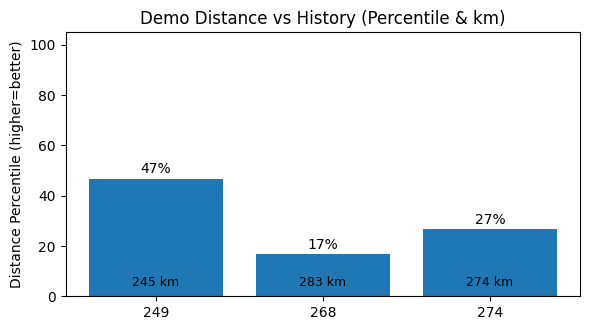

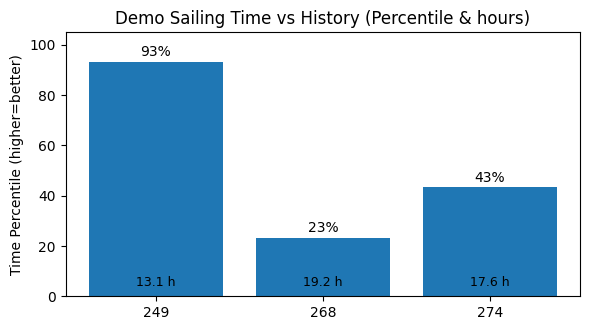

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# 取 demo 的三條
d = summary_demo.copy()
labels = d["voyage_id"].astype(int).astype(str).tolist()

# 距離百分位
fig = plt.figure(figsize=(6,3.4))
vals = d["dist_percentile"].to_numpy(dtype=float)
plt.bar(labels, vals)
for x, v, dist in zip(range(len(labels)), vals, d["distance_km"]):
    plt.text(x, v+1, f"{v:.0f}%", ha="center", va="bottom", fontsize=10)
    plt.text(x, 3, f"{dist:.0f} km", ha="center", va="bottom", fontsize=9)
plt.ylim(0, 105)
plt.ylabel("Distance Percentile (higher=better)")
plt.title("Demo Distance vs History (Percentile & km)")
plt.tight_layout()
plt.show()

# 時間百分位
fig = plt.figure(figsize=(6,3.4))
vals = d["time_percentile"].to_numpy(dtype=float)
plt.bar(labels, vals)
for x, v, hrs in zip(range(len(labels)), vals, d["sailing_hours"]):
    plt.text(x, v+1, f"{v:.0f}%", ha="center", va="bottom", fontsize=10)
    plt.text(x, 3, f"{hrs:.1f} h", ha="center", va="bottom", fontsize=9)
plt.ylim(0, 105)
plt.ylabel("Time Percentile (higher=better)")
plt.title("Demo Sailing Time vs History (Percentile & hours)")
plt.tight_layout()
plt.show()
